Updated model to modify for normalization N and baseline B.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [98]:
real_deconv_combined.save_replication_deconvolution()

Creating directory: data/copy_correction/...Directory exists. Skipping.
Saved to: data/copy_correction//N_combined.npy
Saved to: data/copy_correction//B_combined.npy
Saved to: data/copy_correction//F_combined.npy


In [518]:
from src.GenomeDeconvolution import GenomeDeconvolution

genome_deconvolution = GenomeDeconvolution(save_dir=None)

todo: Copy correction is not in place


In [519]:
from src.RealDataReplication import read_n_fr_b

chrom = 16
deconv_span = 770500, 772000

N, fr, b = read_n_fr_b(chrom, deconv_span)
genome_deconvolution.load_chrom_span(chrom, deconv_span)


Loading chromosome reads: 16
Applying a normalization for length distribution
Loading chromosome reads: 16
Applying a normalization for length distribution
Adding a deconvolution offset to G: 1


In [522]:
genome_deconvolution.combined_model.deconvolve(N=N, f_replication=fr, b=b)

Adding a deconvolution offset to G: 1
Deconvolving combined model with gamma=0.1
Deconvolving bin size: 10x10
of G shape: (31, 3900)
Padding type: both
Deconvolving with gamma=0.1
0/3900 - 00:00:00.143
500/3900 - 00:00:53.102
1000/3900 - 00:01:46.429
1500/3900 - 00:02:38.333
2000/3900 - 00:03:29.619
2500/3900 - 00:04:22.935
3000/3900 - 00:05:18.815
3500/3900 - 00:06:11.163
Deconvolved in : 00:06:53.319
The fitting norm is 4.07, the smoothing norm is: 2.35


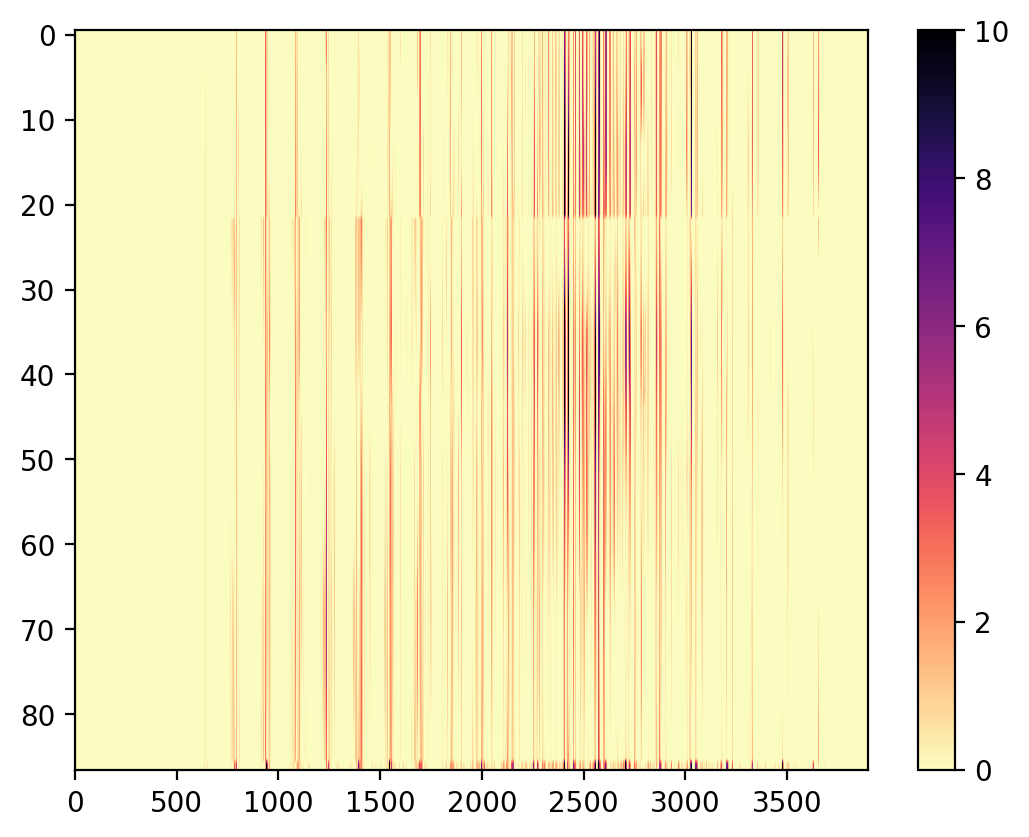

In [523]:
F = genome_deconvolution.combined_model.deconvolved_f_value-1

normalized_F = F
normalized_F_images = normalized_F.reshape((F.shape[0], 26, -1))

plt.imshow(normalized_F, cmap='magma_r', vmin=0., vmax=10, aspect='auto')
plt.colorbar()


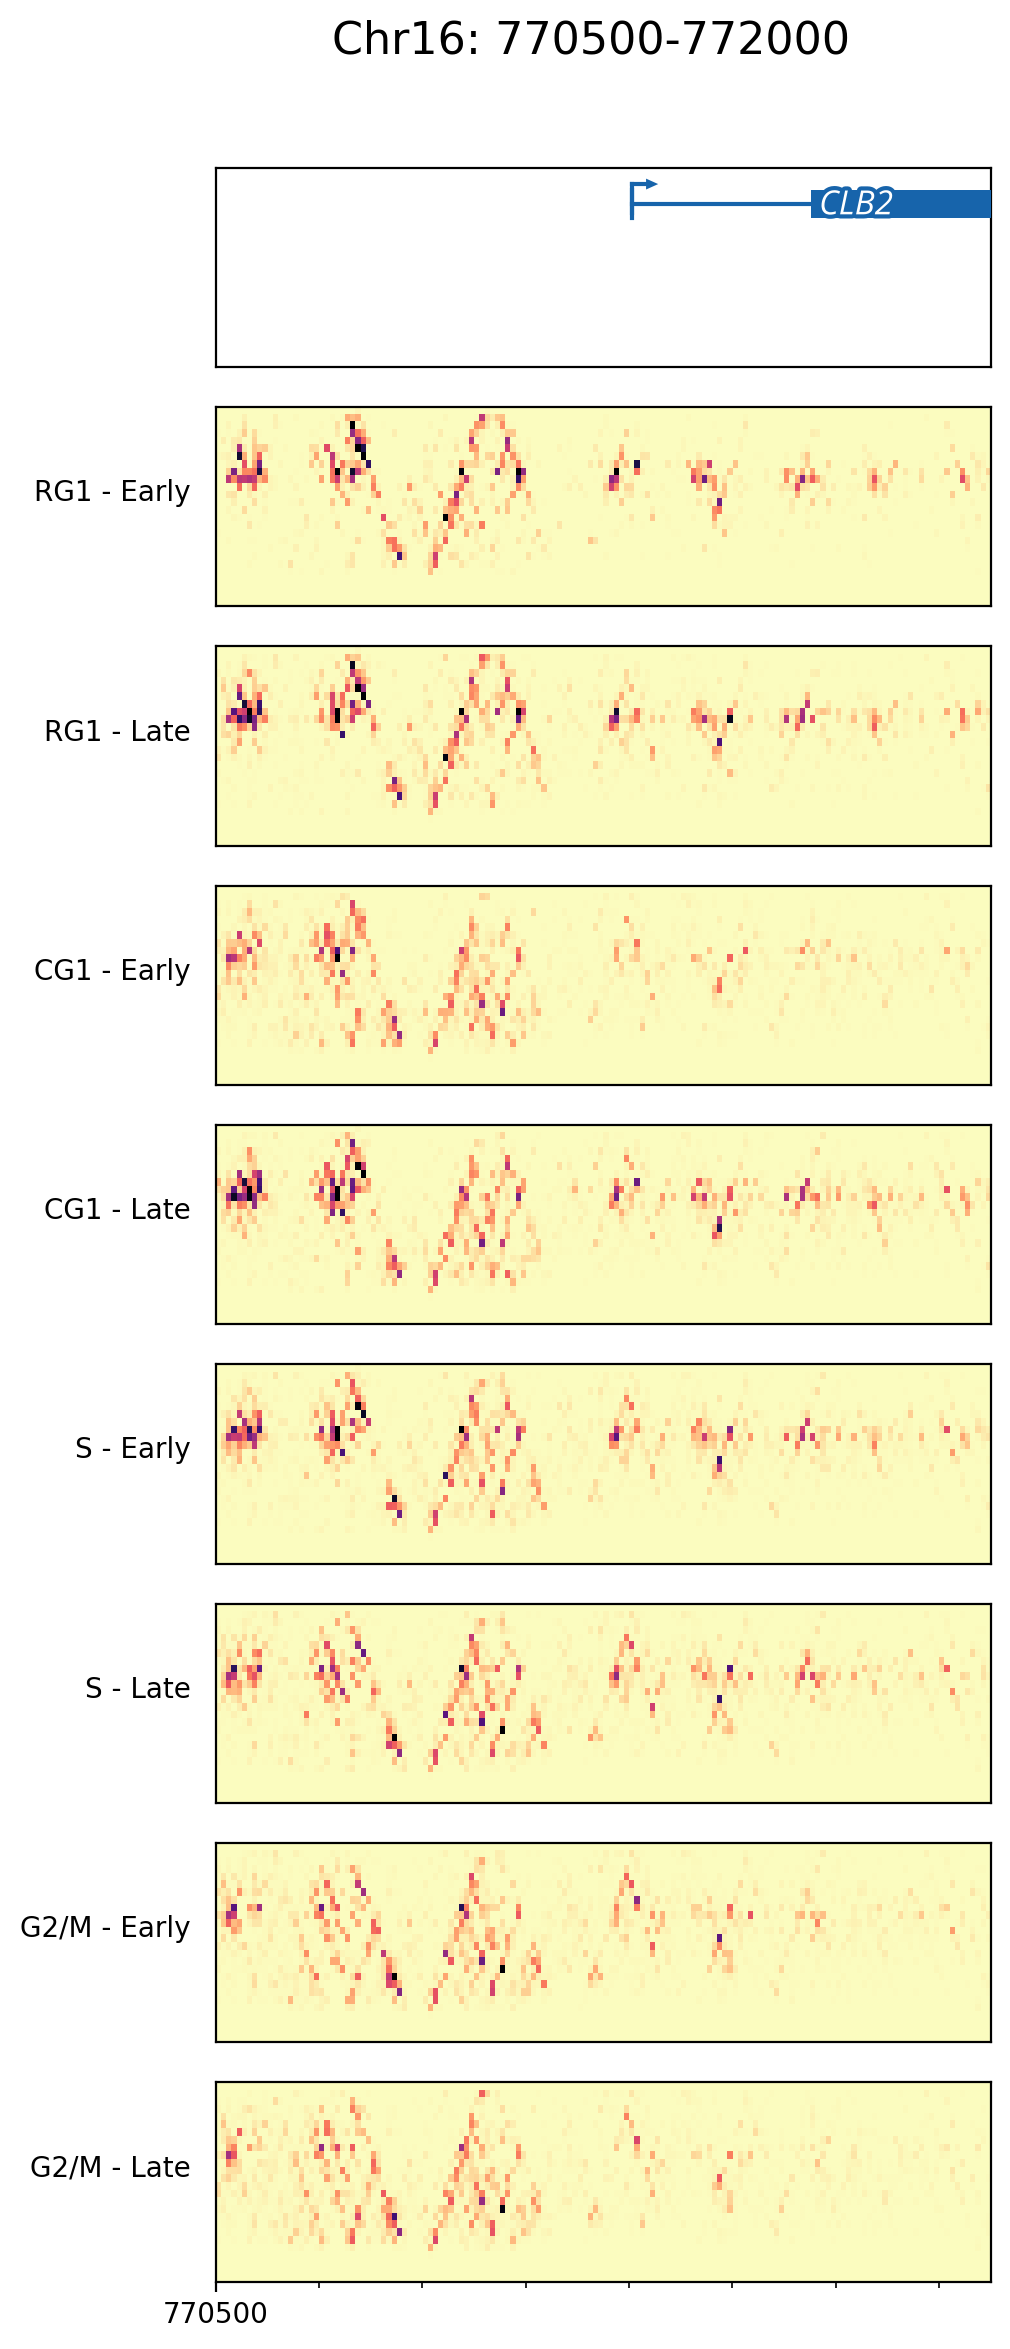

In [545]:
fig = genome_deconvolution.plot_deconvolved_result(figwidth=5, vmin=0.75, vmax=20)